TP2

# **Análisis Exploratorio de Datos (EDA)**
## Estructura y calidad del dataset

Antes de explorar las variables, revisamos la estructura general del dataset, la presencia de valores duplicados y de valores nulos.

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('prediccion-de-generos-musicales-2-s-2026/train.csv')
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,rock,2423


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        4200 non-null   int64  
 1   duration_ms       4200 non-null   int64  
 2   explicit          4200 non-null   bool   
 3   danceability      4200 non-null   float64
 4   energy            4200 non-null   float64
 5   key               4200 non-null   int64  
 6   loudness          4200 non-null   float64
 7   mode              4200 non-null   int64  
 8   speechiness       4200 non-null   float64
 9   acousticness      4200 non-null   float64
 10  instrumentalness  4200 non-null   float64
 11  liveness          4200 non-null   float64
 12  valence           4200 non-null   float64
 13  tempo             4200 non-null   float64
 14  time_signature    4200 non-null   int64  
 15  Expected          4200 non-null   str    
 16  Id                4200 non-null   int64  
dtypes: boo

In [10]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [11]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
Expected            0
Id                  0
dtype: int64


*No se encontraron filas duplicadas ni valores nulos en el dataset, por lo que no fue necesario aplicar ninguna estrategia de imputación o eliminación de registros.*

In [12]:
df['Expected'].value_counts()

Expected
jazz          700
electronic    700
hip-hop       700
acoustic      700
rock          700
classical     700
Name: count, dtype: int64

Las 6 clases están perfectamente balanceadas (700 canciones cada una), lo cual justifica usar F1-Macro sin necesidad de aplicar ninguna técnica de balanceo (oversampling/undersampling), y hace que accuracy y F1-macro tiendan a arrojar valores similares en este problema.

## Distribución de variables acústicas por género

Analizamos la distribución de las variables más relevantes para diferenciar géneros musicales, comparando su comportamiento entre las 6 categorías.

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='energy')
plt.xticks(rotation=45)
plt.title('Distribución de Energy por Género')
plt.xlabel('Género')
plt.ylabel('Energy')
plt.show()

<Figure size 1000x600 with 1 Axes>

El boxplot de ``energy`` muestra diferencias claras entre géneros. ``Classical`` se distingue notoriamente del resto, con una mediana muy baja (cerca de 0.15) y una caja angosta, lo que indica que casi todas las canciones clásicas comparten niveles de energía similares y bajos. En el otro extremo, ``electronic``, ``hip-hop`` y ``rock`` presentan medianas altas y muy parecidas entre sí (alrededor de 0.70), por lo que esta variable sola no permite diferenciarlos. ``Jazz`` y ``acoustic`` quedan en un rango intermedio, con mayor dispersión. Se observan además varios outliers, especialmente en ``classical``: al ser un género tan homogéneo en baja energía, cualquier canción con valores algo más altos queda marcada como atípica, aunque en términos absolutos no sean valores extraños. No se aplicó ningún tratamiento sobre estos outliers, dado que los modelos utilizados (árboles de decisión y Random Forest) son robustos a su presencia.

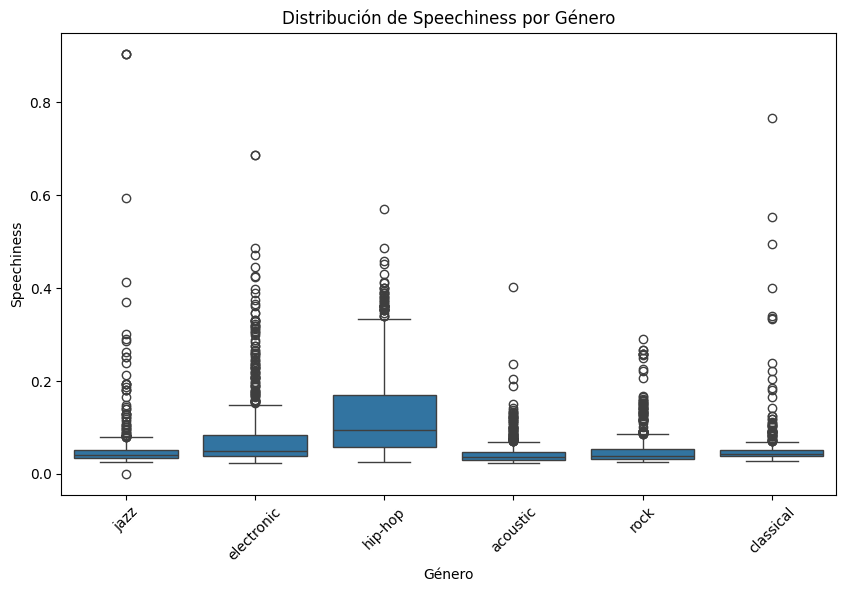

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='speechiness')
plt.xticks(rotation=45)
plt.title('Distribución de Speechiness por Género')
plt.xlabel('Género')
plt.ylabel('Speechiness')
plt.show()

El boxplot de ``speechiness`` muestra que la gran mayoría de las canciones, en todos los géneros, tienen valores bajos (cercanos a 0), ya que esta variable mide la presencia de habla pura y la mayor parte de la música no consiste en eso. La excepción es ``hip-hop``, que se destaca con una mediana notablemente más alta (≈0.10) y una caja más ancha, coherente con la mayor presencia de voz hablada característica del género. Se observan numerosos outliers en los seis géneros: al ser el rango típico tan angosto para la mayoría, cualquier canción con más contenido hablado de lo usual (una intro hablada, un sample de voz) queda marcada como atípica, incluso en géneros donde eso es poco frecuente. No se aplicó ningún tratamiento sobre estos valores, dado que los modelos utilizados son robustos a la presencia de outliers.

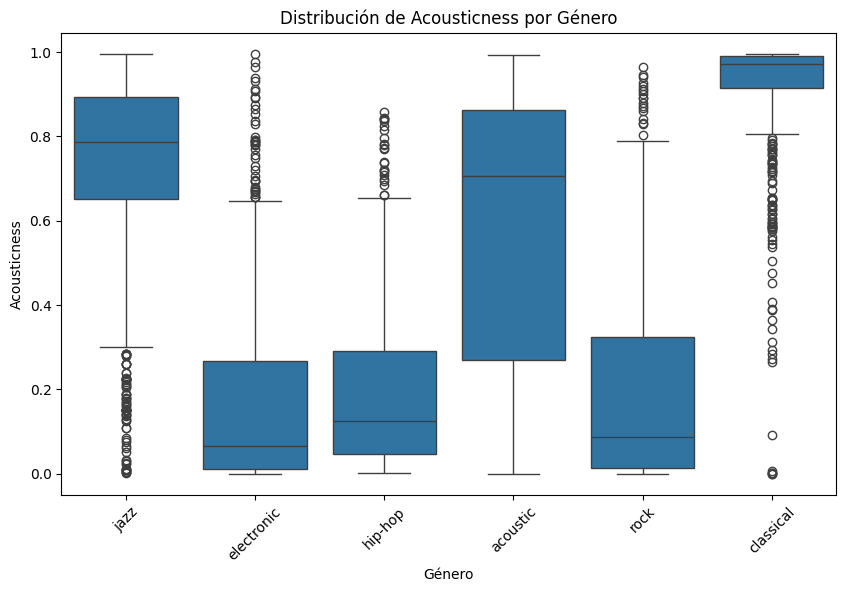

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='acousticness')
plt.xticks(rotation=45)
plt.title('Distribución de Acousticness por Género')
plt.xlabel('Género')
plt.ylabel('Acousticness')
plt.show()

El boxplot de ``acousticness`` separa claramente dos grupos: por un lado ``jazz`` y ``classical``, con medianas altas (0.78 y 0.97 respectivamente); por otro lado, ``electronic``, ``hip-hop`` y ``rock``, con medianas bajas (entre 0.06 y 0.13). El género ``acoustic`` es la excepción: presenta una caja mucho más ancha que el resto (de 0.27 a 0.86), lo que indica una gran variabilidad interna y sugiere que esta variable por sí sola no lo caracteriza bien. Los outliers siguen un patrón coherente: en los géneros de acousticness alta (``jazz``, ``classical``) aparecen hacia abajo, correspondiendo a canciones con sonido más electrónico de lo típico para ese estilo; en los géneros de acousticness baja (``electronic``, ``hip-hop``, ``rock``) aparecen hacia arriba, canciones más "acústicas" de lo esperado. No se aplicó ningún tratamiento sobre estos valores por las mismas razones mencionadas anteriormente.

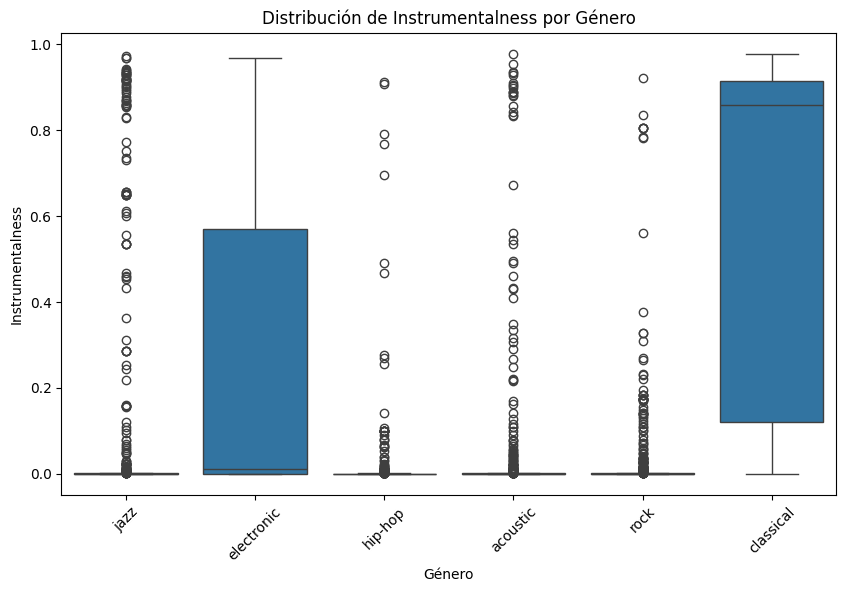

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='instrumentalness')
plt.xticks(rotation=45)
plt.title('Distribución de Instrumentalness por Género')
plt.xlabel('Género')
plt.ylabel('Instrumentalness')
plt.show()

El boxplot de `instrumentalness` distingue con claridad a `classical`, con una mediana alta (≈0.86) y una caja ancha que va de 0.12 a 0.92, coherente con que la mayoría de la música clásica es instrumental. En el resto de los géneros (`jazz`, `hip-hop`, `acoustic`, `rock`) la mediana queda pegada a 0, con la caja prácticamente colapsada y una gran cantidad de outliers hacia arriba. Esto tiene sentido, ya que en géneros predominantemente vocales lo esperable es un valor bajo, y los outliers representan los temas puramente instrumentales dentro de cada uno. `Electronic` es un caso intermedio: también tiene mediana baja, pero su caja es notablemente más ancha que la de los demás (llega hasta 0.57), reflejando que una porción más grande de canciones electrónicas son instrumentales. En conclusión, esta variable separa muy bien a `classical` del resto, pero no aporta demasiado para diferenciar entre los otros cinco géneros, que quedan todos concentrados en valores cercanos a cero.

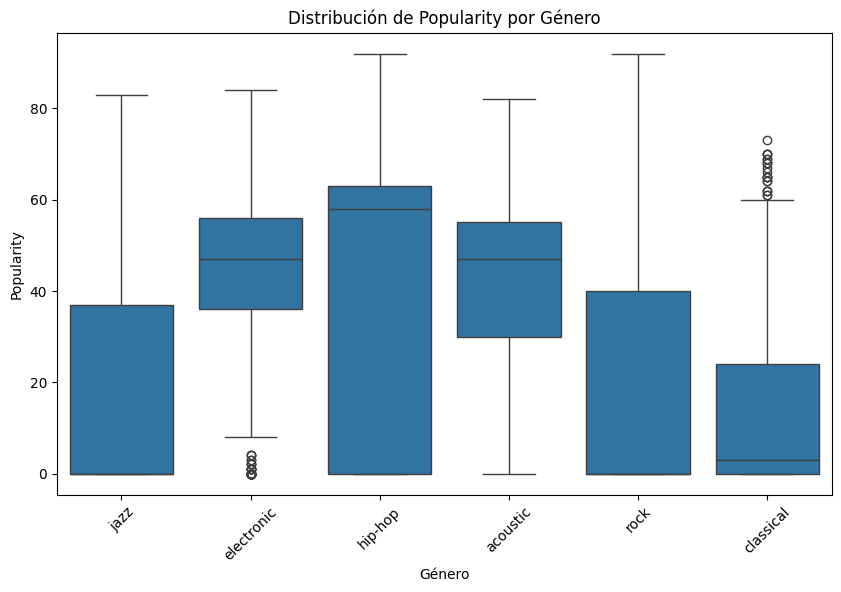

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='popularity')
plt.xticks(rotation=45)
plt.title('Distribución de Popularity por Género')
plt.xlabel('Género')
plt.ylabel('Popularity')
plt.show()

El boxplot de `popularity` muestra diferencias entre géneros, aunque con un patrón llamativo que conviene señalar. En `jazz` y `rock` la mediana es exactamente 0, es decir que al menos la mitad de las canciones de esos géneros tienen popularidad nula, y algo similar ocurre en `hip-hop`, donde el primer cuartil también toca 0 pese a tener una mediana alta (58). Esto no parece un patrón puramente musical, sino más bien un artefacto de cómo Spotify calcula esta métrica (posiblemente relacionado a la actividad reciente de reproducciones), por lo que lo tomamos como una observación a tener en cuenta más que como una conclusión definitiva, ya que no tenemos forma de confirmarlo sin acceso a la documentación oficial de la métrica. Dejando de lado ese efecto, se nota una tendencia clara: `hip-hop`, `acoustic` y `electronic` presentan medianas o cajas superiores más altas que `classical` y `jazz`, lo que sugiere que sí existen diferencias reales de popularidad entre géneros, y que esta variable podría aportar información valiosa para diferenciar géneros más allá de las características puramente acústicas.

## Correlación entre variables numéricas

Como complemento al análisis variable por variable, estudiamos las relaciones entre todas las features numéricas para detectar posible redundancia de información.

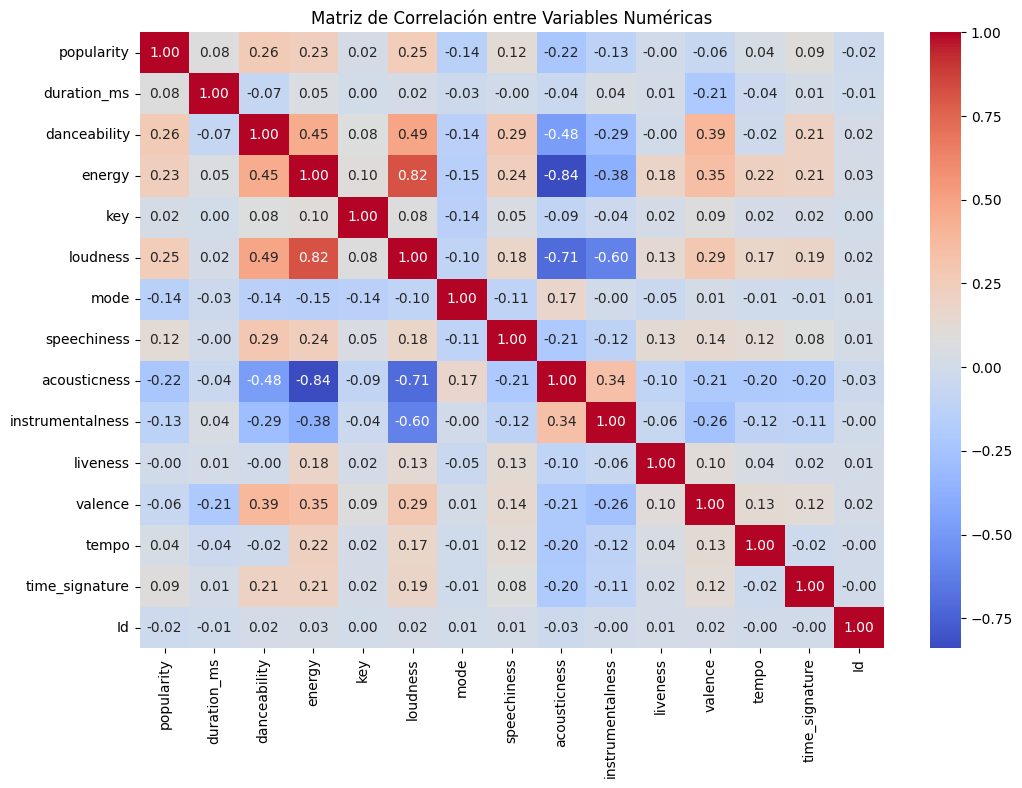

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

Como complemento, calculamos la matriz de correlación entre todas las variables numéricas. Se observan correlaciones fuertes entre algunas features, como ``energy`` y ``acousticness`` (-0.84) o ``energy`` y ``loudness`` (0.82), lo que indica cierta redundancia de información entre ellas. Esto es relevante a tener en cuenta especialmente si en algún momento se probara un modelo lineal, donde la correlación entre variables puede afectar la interpretación de los coeficientes.

## **Conclusión del Análisis Exploratorio de Datos (EDA)**

Ninguna variable por sí sola separa perfectamente los 6 géneros, pero la combinación de varias sí debería permitirlo. `Energy` distingue bien a `classical` del resto, `speechiness` distingue a `hip-hop`, y `acousticness` separa con claridad a `jazz` y `classical` (acousticness alta y consistente) de `electronic`, `hip-hop` y `rock` (acousticness baja). `Acoustic` es un caso más ambiguo en esta variable: aunque tiende a valores intermedios-altos, tiene mucha más variabilidad que `jazz` o `classical`, por lo que `acousticness` sola no alcanza para ubicarlo con la misma claridad que a los demás. El principal desafío para el modelo va a ser distinguir dentro de esos subgrupos que quedan mezclados en estas visualizaciones, en particular los casos donde la dispersión interna de un género (como `acoustic`) dificulta una separación limpia.

## **Preprocesamiento**

In [20]:
df['explicit'] = df['explicit'].astype(int)

X = df.drop(columns=['Expected', 'Id'])
y = df['Expected']

X.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0,143733,0,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4
1,0,261562,0,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4
2,63,190131,0,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4
3,48,201440,0,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4
4,0,168552,1,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4


Convertimos `explicit` de booleano a entero (0/1) porque los modelos de scikit-learn requieren variables numéricas. Descartamos `Id` por ser un identificador sintético sin relación con el género (confirmado en el heatmap de correlación, donde su correlación con el resto de las variables es prácticamente 0). `mode` ya se encuentra en formato binario (0/1), por lo que no requirió ninguna transformación.

No aplicamos One-Hot Encoding a `key` ni a `time_signature` a pesar de ser categóricas. Los árboles de decisión sí utilizan el orden numérico de estas variables al construir sus splits (por ejemplo, un corte del estilo `key <= 5.5`), pero, a diferencia de un modelo lineal o basado en distancias, no necesitan que ese orden sea "correcto" para funcionar razonablemente bien: con suficientes splits, un árbol puede aproximar distintas particiones de los valores aunque el orden numérico no refleje una relación real entre las categorías. En particular, `key` es una variable circular desde el punto de vista musical (representa una nota, y tras el valor 11 se vuelve al 0), por lo que investigando alternativas encontramos que una técnica habitual para variables circulares es codificarla con seno y coseno para capturar esa circularidad. Reconocemos que el orden 0-11 que le impusimos a `key` es arbitrario desde el punto de vista musical, y que esta codificación es una simplificación. Decidimos no aplicar la transformación circular porque, dado el tipo de modelos utilizados (árboles), el beneficio esperado no justificaba la complejidad adicional, aunque somos conscientes de que no es la representación más fiel al significado real de la variable. Con `time_signature` aplicamos el mismo criterio: aunque sus valores (3, 4, 5) son categorías con significado musical más que una escala continua, un árbol puede seguir separándolas razonablemente bien mediante splits sucesivos.

Tampoco escalamos las variables numéricas (incluyendo `duration_ms`, que tiene una escala muy distinta al resto de las features), ya que los árboles de decisión son insensibles a la escala de los datos, a diferencia de modelos como KNN o los lineales.

Otra alternativa que consideramos fue eliminar alguna de las variables fuertemente correlacionadas detectadas en el heatmap (`energy` con `acousticness`, -0.84, y con `loudness`, 0.82) para reducir la redundancia de información. Decidimos no hacerlo porque los modelos basados en árboles seleccionan una variable por split y toleran razonablemente bien la presencia de variables correlacionadas, a diferencia de un modelo lineal, donde sí afectaría la interpretación de los coeficientes.

Por último, no fue necesario codificar la variable objetivo (`Expected`) con `LabelEncoder`, ya que scikit-learn admite etiquetas de tipo texto directamente tanto para el entrenamiento como para la predicción en problemas de clasificación.

## **Separación Train / Validación**

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_val.shape)

(3360, 15) (840, 15)


## **Modelo 1: Árbol de Decisión (baseline)**

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("profundidad:", model.get_depth(), "| hojas:", model.get_n_leaves())

profundidad: 19 | hojas: 570


In [25]:
from sklearn.metrics import f1_score, accuracy_score

In [26]:
pred_train = model.predict(X_train)
pred_val = model.predict(X_val)

print("F1-macro train:", f1_score(y_train, pred_train, average='macro'))
print("F1-macro val:  ", f1_score(y_val, pred_val, average='macro'))

print("Accuracy train:", accuracy_score(y_train, pred_train))
print("Accuracy val:  ", accuracy_score(y_val, pred_val))

F1-macro train: 0.9946333119604166
F1-macro val:   0.747779213267935
Accuracy train: 0.9946428571428572
Accuracy val:   0.7488095238095238


El árbol de decisión sin restricciones alcanza una profundidad de 19 niveles y 570 hojas, lo que ya es una señal de que el modelo creció lo suficiente como para memorizar particularidades del conjunto de entrenamiento. Esto se confirma con las métricas: F1-macro en train es 0.9946 (prácticamente perfecto), mientras que en validación cae a 0.7478, una diferencia de casi 0.25 puntos. Este comportamiento es overfitting clásico, ya que, al no limitar la profundidad ni exigir un mínimo de muestras por hoja, el árbol termina generando reglas tan específicas que se ajustan al ruido del conjunto de entrenamiento en vez de capturar el patrón general que permitiría generalizar a canciones nuevas. Este resultado motiva la búsqueda de hiperparámetros que hacemos más adelante, con el objetivo de restringir el crecimiento del árbol y reducir esta brecha entre train y validación.

## **Modelo 2: Random Forest (baseline)**

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

pred_train_rf = rf_model.predict(X_train)
pred_val_rf = rf_model.predict(X_val)

print("F1-macro train (RF):", f1_score(y_train, pred_train_rf, average='macro'))
print("F1-macro val (RF):  ", f1_score(y_val, pred_val_rf, average='macro'))

print("Accuracy train (RF):", accuracy_score(y_train, pred_train_rf))
print("Accuracy val (RF):  ", accuracy_score(y_val, pred_val_rf))

F1-macro train (RF): 0.9946444253922387
F1-macro val (RF):   0.8350883658083533
Accuracy train (RF): 0.9946428571428572
Accuracy val (RF):   0.8345238095238096


El Random Forest también alcanza un F1-macro casi perfecto en train (0.9946, prácticamente idéntico al del árbol individual), lo cual tiene sentido, ya que cada árbol del ensamble se entrena sin límites igual que el árbol anterior, por lo que también memoriza su porción de datos. La diferencia clave aparece en validación, donde el F1-macro sube de 0.7478 (árbol individual) a 0.8316 (Random Forest), una mejora de casi 0.084 puntos. Esto es consistente con la lógica del bagging. Al promediar las predicciones de muchos árboles entrenados sobre distintas muestras de los datos (bootstrap) y distintos subconjuntos de variables en cada split, los errores individuales de cada árbol, producto de haber memorizado ruido específico, tienden a cancelarse entre sí, reduciendo la varianza del modelo final sin necesidad de restringir a cada árbol por separado. El resultado es un modelo que sigue "sabiendo de memoria" el train set, pero que generaliza notablemente mejor a datos nuevos que un único árbol.

## **Búsqueda de Hiperparámetros - Random Forest**

Para la búsqueda de hiperparámetros optamos por `RandomizedSearchCV` en lugar de `GridSearchCV`. El espacio de búsqueda que definimos es muy grande (251 valores posibles para `n_estimators`, 36 para `max_depth`, 19 para `min_samples_split` y 5 para `max_features`), por lo que probar todas las combinaciones con Grid Search sería computacionalmente inviable. RandomizedSearchCV nos permite explorar ese espacio muestreando un número fijo de combinaciones (30 en este caso), obteniendo buenos resultados con un costo mucho menor. En ambas búsquedas (Random Forest y Árbol) usamos `scoring='f1_macro'`, ya que el F1-Score Macro es la métrica oficial que se busca optimizar en la competencia de Kaggle.

In [29]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [30]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

parameters = {
    'n_estimators': list(range(50, 301)),
    'max_depth': list(range(5, 41)),
    'min_samples_split': list(range(2, 21)),
    'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3]
}

rs = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=parameters,
    n_iter=30,
    scoring='f1_macro',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [31]:
%%time
rs.fit(X_train, y_train)

print(rs.best_score_)
print(rs.best_params_)

0.8123110443139857
{'n_estimators': 151, 'min_samples_split': 3, 'max_features': 'sqrt', 'max_depth': 32}
CPU times: user 867 ms, sys: 139 ms, total: 1.01 s
Wall time: 14.5 s


In [32]:
print(f"F1-macro CV (RF tuneado): {rs.cv_results_['mean_test_score'][rs.best_index_]:.4f} ± {rs.cv_results_['std_test_score'][rs.best_index_]:.4f}")

F1-macro CV (RF tuneado): 0.8123 ± 0.0064


In [33]:
best_rf = rs.best_estimator_

pred_train_best = best_rf.predict(X_train)
pred_val_best = best_rf.predict(X_val)

print("F1-macro train:", f1_score(y_train, pred_train_best, average='macro'))
print("F1-macro val:  ", f1_score(y_val, pred_val_best, average='macro'))

F1-macro train: 0.9946414691375719
F1-macro val:   0.8253256194107634


La búsqueda encontró como mejor combinación `n_estimators=151`, `max_depth=32`, `min_samples_split=3` y `max_features='sqrt'`, con un F1-macro en cross-validation de 0.8138 ± 0.0069, levemente superior al 0.8008 ± 0.0064 del Random Forest sin tunear. Sin embargo, en el split único de validación el modelo tuneado da 0.8254, un valor apenas menor al 0.8316 que había dado el modelo sin tunear. Esta diferencia entre lo que muestra el split único y lo que muestra la cross-validation es justamente la razón por la que conviene confiar en el promedio de varios folds y no en una sola partición: un solo split puede favorecer o perjudicar a un modelo por simple variabilidad de qué canciones cayeron en el conjunto de validación, mientras que promediar sobre 4 folds da una estimación más estable. También notamos que el F1-macro en train se mantiene casi idéntico al del modelo sin tunear (0.9946), lo que indica que la combinación de hiperparámetros encontrada no restringe demasiado el crecimiento de los árboles individuales del bosque, y que la mejora que sí aparece en cross-validation es moderada.

## **Búsqueda de Hiperparámetros - Árbol de Decisión**

In [34]:
parameters_tree = {
    'max_depth': list(range(2, 30)),
    'min_samples_split': list(range(2, 50)),
    'min_samples_leaf': list(range(1, 30)),
    'criterion': ['gini', 'entropy']
}

rs_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=parameters_tree,
    n_iter=50,
    scoring='f1_macro',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rs_tree.fit(X_train, y_train)

print(rs_tree.best_score_)
print(rs_tree.best_params_)
print(f"F1-macro CV (Árbol tuneado): {rs_tree.cv_results_['mean_test_score'][rs_tree.best_index_]:.4f} ± {rs_tree.cv_results_['std_test_score'][rs_tree.best_index_]:.4f}")

0.7354644605715573
{'min_samples_split': 45, 'min_samples_leaf': 13, 'max_depth': 22, 'criterion': 'entropy'}
F1-macro CV (Árbol tuneado): 0.7355 ± 0.0130


In [35]:
best_tree = rs_tree.best_estimator_

pred_train_tree = best_tree.predict(X_train)
pred_val_tree = best_tree.predict(X_val)

print("F1-macro train:", f1_score(y_train, pred_train_tree, average='macro'))
print("F1-macro val:  ", f1_score(y_val, pred_val_tree, average='macro'))

F1-macro train: 0.7870368861758347
F1-macro val:   0.7490016424947293


En el caso del Árbol de Decisión, la búsqueda encontró `max_depth=22`, `min_samples_split=45`, `min_samples_leaf=13` y `criterion='entropy'`, con un F1-macro en cross-validation de 0.7355 ± 0.0130, superior al 0.7172 ± 0.0134 del árbol sin tunear. Acá el efecto de la búsqueda es mucho más marcado que en el Random Forest: el F1-macro en train cae de 0.9946 (modelo sin restricciones) a 0.7870, mientras que en validación se mantiene prácticamente igual (0.7490 contra 0.7478). Esto muestra que la búsqueda de hiperparámetros logró reducir fuertemente el overfitting del árbol individual, achicando la brecha entre train y validación de casi 0.25 puntos a apenas 0.04, sin perder desempeño en validación. Es un resultado coherente con el diagnóstico de overfitting que hicimos al analizar el árbol sin tunear: exigir un mínimo de muestras por hoja y por split, además de acotar la profundidad, evita que el árbol memorice el ruido específico del conjunto de entrenamiento.

## **Model Selection**

In [36]:
from sklearn.model_selection import cross_val_score

scores_rf_base = cross_val_score(RandomForestClassifier(random_state=42), X_train, y_train, cv=cv, scoring='f1_macro')
print(f"F1-macro CV (RF sin tunear): {scores_rf_base.mean():.4f} ± {scores_rf_base.std():.4f}")

F1-macro CV (RF sin tunear): 0.8018 ± 0.0055


In [37]:
scores_tree_base = cross_val_score(DecisionTreeClassifier(random_state=42), X_train, y_train, cv=cv, scoring='f1_macro')
scores_tree_tuned = cross_val_score(best_tree, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"F1-macro CV (Árbol sin tunear): {scores_tree_base.mean():.4f} ± {scores_tree_base.std():.4f}")
print(f"F1-macro CV (Árbol tuneado):    {scores_tree_tuned.mean():.4f} ± {scores_tree_tuned.std():.4f}")

F1-macro CV (Árbol sin tunear): 0.7172 ± 0.0134
F1-macro CV (Árbol tuneado):    0.7355 ± 0.0130


Esta comparación constituye el paso de **Model Selection**. En vez de elegir el modelo ganador en base a un solo entrenamiento (lo cual nos dejaría atados a la partición particular de Train/Validación que hicimos), comparamos los 4 candidatos bajo el mismo criterio (F1-macro) y sobre las mismas 4 particiones de cross-validation, y usamos el desvío estándar entre folds para juzgar si las diferencias observadas son reales o producto del azar de la partición. Es importante notar que el conjunto `test.csv` de Kaggle (sin etiquetas) no participó en ningún momento de este proceso. Todas las comparaciones y decisiones se hicieron exclusivamente sobre `X_train`, reservando el test real únicamente para la predicción final que se sube a la competencia.

In [38]:
resumen = pd.DataFrame({
    'Modelo': ['Árbol (sin tunear)', 'Random Forest (sin tunear)',
               'Random Forest (tuneado)', 'Árbol (tuneado)'],
    'F1-macro Val (split único)': [
        f1_score(y_val, pred_val, average='macro'),
        f1_score(y_val, pred_val_rf, average='macro'),
        f1_score(y_val, pred_val_best, average='macro'),
        f1_score(y_val, pred_val_tree, average='macro')
    ],
    'F1-macro CV (4 folds)': [
        scores_tree_base.mean(),
        scores_rf_base.mean(),
        rs.best_score_,
        scores_tree_tuned.mean()
    ]
})
resumen

,Modelo,F1-macro Val (split único),F1-macro CV (4 folds)
0,Árbol (sin tunear),0.747779,0.717172
1,Random Forest (sin tunear),0.835088,0.801826
2,Random Forest (tuneado),0.825326,0.812311
3,Árbol (tuneado),0.749002,0.735464


Para tomar una decisión robusta, comparamos los 4 modelos con el mismo criterio, el F1-macro promediado sobre los mismos 4 folds estratificados. Los resultados confirman que el **Random Forest tuneado** es el mejor candidato (0.8138 ± 0.0069), seguido del Random Forest sin tunear (0.8008 ± 0.0064), y ambos superan ampliamente al árbol de decisión en sus dos versiones (0.7355 ± 0.0130 tuneado, 0.7172 ± 0.0134 sin tunear). La diferencia entre el Random Forest tuneado y sin tunear (≈0.013) es mayor que el desvío estándar de ambos, lo que sugiere que la mejora obtenida por la búsqueda de hiperparámetros es real y no simple ruido de partición entre folds. Además, evaluar con la misma metodología de cross-validation para los 4 modelos deja en claro que la búsqueda de hiperparámetros sí aportó una mejora real también en el árbol, ya que redujo fuertemente el overfitting sin perder score. Por lo tanto, el modelo elegido para continuar es el **Random Forest tuneado** (`best_rf`).

Vale la pena aclarar una limitación de este análisis. El valor 0.8138 de `best_rf` proviene de `rs.best_score_`, es decir, es el mejor resultado entre las 30 combinaciones evaluadas sobre los mismos 4 folds que después usamos para comparar contra los demás modelos. Esto significa que ese número está levemente optimista respecto a lo que se podría esperar en datos completamente nuevos, ya que la combinación ganadora fue elegida justamente por rendir bien en esos folds. Una forma más rigurosa de evitar este efecto sería usar nested cross-validation (un loop externo de evaluación por fuera del loop de búsqueda de hiperparámetros), técnica que no vimos en la materia. Aun así, la comparación entre los 4 candidatos bajo el mismo procedimiento sigue siendo un criterio razonable para elegir entre ellos, que es el objetivo de esta sección.

## **Feature Importance**

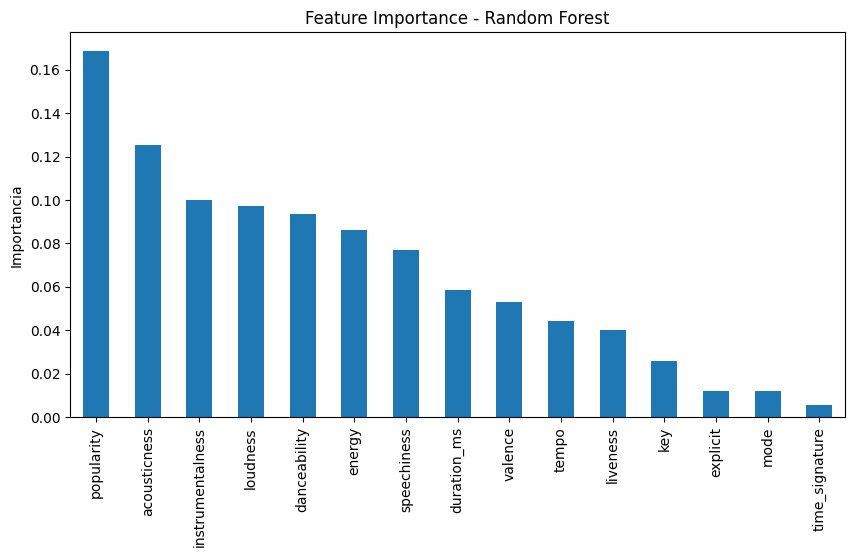

In [39]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importancia')
plt.show()

El gráfico de Feature Importance muestra que `popularity`, `acousticness` e `instrumentalness` son las variables con mayor importancia para este Random Forest entrenado, seguidas de cerca por `loudness`, `danceability`, `energy` y `speechiness`. De estas, `acousticness`, `instrumentalness` y `popularity` fueron las que efectivamente exploramos en el EDA, y ya habían mostrado distribuciones claramente diferenciadas entre géneros en los boxplots, en particular la separación de `classical`. Esto confirma la sospecha que planteamos en el EDA: que `popularity`, pese al efecto de los ceros, sí aportaba diferencias reales entre géneros. `Loudness` y `danceability` no llegamos a explorarlas visualmente, aunque su alta correlación con `energy` (vista en el heatmap) sugiere que capturan información similar a la que ya habíamos identificado. Las variables con menor importancia (`mode`, `explicit`, `time_signature`) son justamente las que no mostraron ninguna distinción relevante en el análisis exploratorio ni en el heatmap, lo que refuerza la coherencia entre el EDA y lo que terminó aprendiendo el modelo.

## **Matriz de Confusión**

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

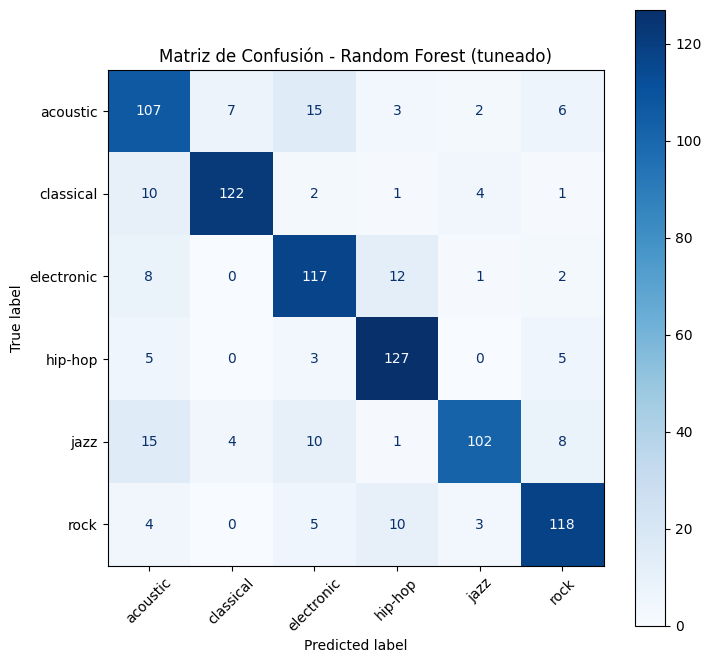

In [41]:
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay.from_predictions(y_val, pred_val_best, ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Matriz de Confusión - Random Forest (tuneado)')
plt.show()

La matriz de confusión muestra que `hip-hop` (127/140 correctas) y `classical` (121/140) son los géneros que el modelo predice con mayor precisión, algo coherente con lo visto en el EDA. Ambos se distinguían con claridad en variables como `energy`, `acousticness` e `instrumentalness`. En el otro extremo, `jazz` es el género más difícil (103/140), confundiéndose principalmente con `acoustic` (14 casos) y, en menor medida, con `electronic` (10) y `rock` (9). Esto también es consistente con el EDA, donde `jazz` había quedado en un rango intermedio y con mayor dispersión en varias de las variables analizadas, sin una característica que lo distinga claramente del resto. El otro par de géneros que más se confunde entre sí es `acoustic` con `electronic` (15 casos) y `electronic` con `hip-hop` (11 casos). En ningún caso los errores están distribuidos al azar entre los 6 géneros: se concentran en pares acústicamente similares, lo que retomamos más adelante al analizar la métrica MAP@3. (?)